# Analytics dashboard for data streams

In [2]:
!pip install numpy==1.26.4 river --force-reinstall -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 4.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 74.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 22.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 69.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.2/35.2 MB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 229.9/229.9 kB 15.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 510.5/510.5 kB 28.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 349.3/349.3 kB 20.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires 

In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt
from river import compose, preprocessing, linear_model, metrics, stream, tree, datasets, drift
from collections import deque
from IPython.display import display
from river.datasets import synth
import pandas as pd


## Class — Real-time analytics dashboard
4×2 Dashboard (8 plots) inspired by Webb et al. (2018):

Decision boundary — dynamic top-2 features

Error heatmap — the same top-2 features

Feature importance — animated top-N bar chart

Performance metric (accuracy / kappa / f1)

Rolling accuracy separately for class 0 and class 1

Prediction confidence margin (EMA)

Feature drift heatmap: features × time, color = deviation from reference (σ)

Prior drift: class distribution in reference vs. current window

In [2]:
class StreamDashboard:
    def __init__(self, model, feature_names, metric_type="accuracy",
                 window_size=300, ref_lag=500, update_freq=100, top_n_features=10):
        """
        General-purpose analytics dashboard for data streams with any number of features.

        :param model:          Main classifier from the river library.
        :param feature_names:  List of all feature names.
        :param metric_type:    "accuracy", "kappa" or "f1".
        :param window_size:    Current window size (spatial samples).
        :param ref_lag:        How many steps back the reference window starts.
                               Ref window = samples [step-ref_lag-window_size : step-ref_lag].
        :param update_freq:    How often (in steps) to refresh the dashboard.
        :param top_n_features: How many features to show on plots 3 and 7.
        """
        self.model         = model
        self.feature_names = list(feature_names)
        self.window_size   = window_size
        self.ref_lag       = ref_lag
        self.update_freq   = update_freq
        self.top_n         = top_n_features
        self.step          = 0
        self.display_handle = None

        # Two currently most important features
        self.top2 = self.feature_names[:2]

        # Metric selection
        if metric_type == "kappa":
            self.metric = metrics.CohenKappa()
        elif metric_type == "f1":
            self.metric = metrics.F1()
        else:
            self.metric = metrics.Accuracy()
        self.metric_name = metric_type.upper()

        # Buffers - long enough to hold current window + lag + reference window
        buf = window_size + ref_lag + window_size
        self.X_hist    = deque(maxlen=buf)   # dicts
        self.y_hist    = deque(maxlen=buf)
        self.pred_hist = deque(maxlen=buf)

        # Buffers for rolling accuracy per class (last 100 samples)
        self.roll_y    = deque(maxlen=100)
        self.roll_pred = deque(maxlen=100)

        # Long-term history
        self.steps_hist       = []
        self.weights_hist     = {}   # {feature: [weights over time]}
        self.metric_hist      = []
        self.conf_margin_hist = []
        self.roll_acc0_hist   = []   # rolling accuracy klasy 0
        self.roll_acc1_hist   = []   # rolling accuracy klasy 1
        # Feature drift: {feature: [mean deviation over time]}
        self.feat_drift_hist  = {}

        # Auxiliary model for feature weights
        self.weight_model = compose.Pipeline(
            preprocessing.StandardScaler(),
            linear_model.LogisticRegression()
        )

        # Layout 4x2 — 8 plots:
        # [1 Decision boundary]   [2 Error heatmap]
        # [3 Feature importance]  [4 Quality metric]
        # [5 Rolling acc/class]   [6 Confidence margin]
        # [7 Feature drift hmap]  [8 Class dist: ref vs current]
        plt.ioff()
        self.fig, self.axes = plt.subplots(
            4, 2, figsize=(16, 24),
            gridspec_kw={"hspace": 0.45, "wspace": 0.3}
        )
        self.ax1, self.ax2, self.ax3, self.ax4,         self.ax5, self.ax6, self.ax7, self.ax8 = self.axes.flatten()
        self.fig.suptitle("Stream Analytics Dashboard (Webb et al.)", fontsize=18)

        # Error heatmap colorbar — created once
        dummy = self.ax2.imshow([[0, 1]], cmap="RdYlGn_r", vmin=0, vmax=1)
        self.colorbar_err = self.fig.colorbar(dummy, ax=self.ax2, label="Error rate")
        self.ax2.cla()

        # Feature drift colorbar — created once
        dummy7 = self.ax7.imshow([[0, 1]], cmap="RdBu_r", vmin=-1, vmax=1)
        self.colorbar_drift = self.fig.colorbar(dummy7, ax=self.ax7, label="Deviation from reference (σ)")
        self.ax7.cla()

        plt.close(self.fig)

    # ------------------------------------------------------------------
    # Helper functions
    # ------------------------------------------------------------------

    def _get_top2(self):
        """Return the 2 features with the highest absolute weight in the auxiliary model."""
        weights = self.weight_model["LogisticRegression"].weights
        if not weights:
            return self.feature_names[:2]
        sorted_f = sorted(weights, key=lambda f: abs(weights.get(f, 0)), reverse=True)
        top2 = [f for f in sorted_f if f in self.feature_names][:2]
        for f in self.feature_names:
            if len(top2) >= 2:
                break
            if f not in top2:
                top2.append(f)
        return top2

    def _mean_context(self, f1, f2):
        """Mean values of all non-top-2 features in the current window — used as frozen context for boundary plotting."""
        ctx = {}
        X_list = list(self.X_hist)[-self.window_size:]
        for fname in self.feature_names:
            if fname in (f1, f2):
                continue
            vals = [x[fname] for x in X_list if fname in x]
            ctx[fname] = float(np.mean(vals)) if vals else 0.0
        return ctx

    def _ref_and_cur_windows(self):
        """
        Return (X_ref, y_ref, X_cur, y_cur) as lists of dicts / arrays.
        Current window  = last window_size samples.
        Reference window = window_size samples ending ref_lag steps ago.
        """
        all_X = list(self.X_hist)
        all_y = list(self.y_hist)
        n = len(all_X)

        cur_X = all_X[-self.window_size:]
        cur_y = np.array(all_y[-self.window_size:])

        ref_end   = max(0, n - self.ref_lag)
        ref_start = max(0, ref_end - self.window_size)
        ref_X = all_X[ref_start:ref_end]
        ref_y = np.array(all_y[ref_start:ref_end])

        return ref_X, ref_y, cur_X, cur_y

    # ------------------------------------------------------------------
    # Main loop
    # ------------------------------------------------------------------

    def update(self, x, y, y_pred):
        """Process one sample from the stream."""
        self.step += 1

        if y_pred is not None:
            self.metric.update(y, y_pred)

        self.X_hist.append(dict(x))
        self.y_hist.append(y)
        self.pred_hist.append(y_pred)
        self.roll_y.append(y)
        self.roll_pred.append(y_pred)
        self.weight_model.learn_one(x, y)

        if self.step % 10 == 0:
            self.steps_hist.append(self.step)

            # Feature weights
            weights = self.weight_model["LogisticRegression"].weights
            for fname in self.feature_names:
                if fname not in self.weights_hist:
                    self.weights_hist[fname] = []
                self.weights_hist[fname].append(abs(weights.get(fname, 0)))

            # Update top-2
            self.top2 = self._get_top2()

            # Global metric
            self.metric_hist.append(self.metric.get())

            # Confidence margin (EMA)
            p = self.model.predict_proba_one(x)
            margin = abs(p.get(1, 0.5) - p.get(0, 0.5))
            smoothed = margin if not self.conf_margin_hist                 else self.conf_margin_hist[-1] * 0.9 + margin * 0.1
            self.conf_margin_hist.append(smoothed)

            # Rolling accuracy per class (last 100 samples)
            ry = np.array(self.roll_y)
            rp = np.array(self.roll_pred)
            for cls, hist in [(0, self.roll_acc0_hist), (1, self.roll_acc1_hist)]:
                mask = ry == cls
                if mask.sum() > 0:
                    hist.append((rp[mask] == cls).mean())
                else:
                    hist.append(np.nan)

            # Feature drift — deviation of current mean from reference mean (in sigmas)
            ref_X, _, cur_X, _ = self._ref_and_cur_windows()
            if len(ref_X) >= 10 and len(cur_X) >= 10:
                for fname in self.feature_names:
                    ref_vals = np.array([x[fname] for x in ref_X if fname in x])
                    cur_vals = np.array([x[fname] for x in cur_X if fname in x])
                    if len(ref_vals) < 2:
                        drift = 0.0
                    else:
                        ref_std = ref_vals.std()
                        drift = (cur_vals.mean() - ref_vals.mean()) / (ref_std + 1e-9)
                        drift = float(np.clip(drift, -3, 3))  # clip to ±3σ
                    if fname not in self.feat_drift_hist:
                        self.feat_drift_hist[fname] = []
                    self.feat_drift_hist[fname].append(drift)

        if self.step % self.update_freq == 0 and self.step > self.ref_lag:
            self._draw()

    # ------------------------------------------------------------------
    # Plots
    # ------------------------------------------------------------------

    def _draw(self):
        """Refresh all dashboard plots."""
        COLORS = {
            "bg":       "#1e1e2e",
            "panel":    "#2a2a3e",
            "text":     "#cdd6f4",
            "subtext":  "#a6adc8",
            "blue":     "#89b4fa",
            "red":      "#f38ba8",
            "green":    "#a6e3a1",
            "yellow":   "#f9e2af",
            "orange":   "#fab387",
            "purple":   "#cba6f7",
            "teal":     "#94e2d5",
            "grid":     "#313244",
        }

        self.fig.patch.set_facecolor(COLORS["bg"])
        for ax in self.axes.flatten():
            ax.clear()
            ax.set_facecolor(COLORS["panel"])
            ax.tick_params(colors=COLORS["subtext"], labelsize=8)
            for spine in ax.spines.values():
                spine.set_edgecolor(COLORS["grid"])

        def style_ax(ax, title, xlabel=None, ylabel=None):
            ax.set_title(title, color=COLORS["text"], fontsize=9, pad=6, fontweight="bold")
            if xlabel:
                ax.set_xlabel(xlabel, color=COLORS["subtext"], fontsize=8)
            if ylabel:
                ax.set_ylabel(ylabel, color=COLORS["subtext"], fontsize=8)
            ax.tick_params(colors=COLORS["subtext"])
            ax.grid(color=COLORS["grid"], linewidth=0.5, linestyle="--", alpha=0.6)

        f1, f2 = self.top2
        cur_X_list = list(self.X_hist)[-self.window_size:]
        y_arr    = np.array(list(self.y_hist)[-self.window_size:])
        pred_arr = np.array(list(self.pred_hist)[-self.window_size:])

        v1 = np.array([x[f1] for x in cur_X_list])
        v2 = np.array([x[f2] for x in cur_X_list])
        x_min, x_max = v1.min(), v1.max()
        y_min, y_max = v2.min(), v2.max()

        # Context — frozen means of non-top-2 features
        context = self._mean_context(f1, f2)
        ctx_str = ", ".join(f"{k}={v:.2f}" for k, v in list(context.items())[:3])
        if len(context) > 3:
            ctx_str += f" +{len(context)-3} more"

        # --- Plot 1: Decision boundary ---
        xx, yy = np.meshgrid(np.linspace(x_min, x_max, 35),
                              np.linspace(y_min, y_max, 35))
        grid_pts = [{**context, f1: a, f2: b} for a, b in zip(xx.ravel(), yy.ravel())]
        Z = np.array([self.model.predict_one(pt) or 0 for pt in grid_pts]).reshape(xx.shape)
        self.ax1.contourf(xx, yy, Z, alpha=0.25, cmap="coolwarm")
        sc1 = self.ax1.scatter(v1, v2, c=y_arr, cmap="coolwarm",
                               edgecolors=COLORS["grid"], s=18, linewidths=0.4, alpha=0.85)
        style_ax(self.ax1,
                 f"Decision boundary  [step: {self.step}]",
                 xlabel=f"► {f1}  (top-1)",
                 ylabel=f"► {f2}  (top-2)")
        if context:
            self.ax1.text(0.01, 0.01, f"frozen: {ctx_str}",
                          transform=self.ax1.transAxes,
                          fontsize=6.5, color=COLORS["subtext"],
                          va="bottom", ha="left",
                          bbox=dict(boxstyle="round,pad=0.2", fc=COLORS["bg"], alpha=0.7))

        # --- Plot 2: Error heatmap ---
        errors = (y_arr != pred_arr).astype(float)
        bins = 20
        xe = np.linspace(x_min, x_max, bins + 1)
        ye = np.linspace(y_min, y_max, bins + 1)
        err_sum, _, _ = np.histogram2d(v1, v2, bins=[xe, ye], weights=errors)
        counts,  _, _ = np.histogram2d(v1, v2, bins=[xe, ye])
        with np.errstate(invalid="ignore"):
            error_rate = np.where(counts > 0, err_sum / counts, np.nan)
        im2 = self.ax2.imshow(
            error_rate.T, origin="lower", aspect="auto",
            extent=[x_min, x_max, y_min, y_max],
            cmap="RdYlGn_r", vmin=0, vmax=1
        )
        self.colorbar_err.update_normal(im2)
        self.colorbar_err.ax.yaxis.set_tick_params(color=COLORS["subtext"])
        plt.setp(self.colorbar_err.ax.yaxis.get_ticklabels(), color=COLORS["subtext"], fontsize=7)
        self.colorbar_err.set_label("Error rate", color=COLORS["subtext"])
        style_ax(self.ax2,
                 f"Error heatmap  [step: {self.step}]",
                 xlabel=f"► {f1}  (top-1)",
                 ylabel=f"► {f2}  (top-2)")
        if context:
            self.ax2.text(0.01, 0.01, f"frozen: {ctx_str}",
                          transform=self.ax2.transAxes,
                          fontsize=6.5, color=COLORS["subtext"],
                          va="bottom", ha="left",
                          bbox=dict(boxstyle="round,pad=0.2", fc=COLORS["bg"], alpha=0.7))

        # --- Plot 3: Feature importance ---
        if self.weights_hist:
            last_w = {f: self.weights_hist[f][-1]
                      for f in self.weights_hist if self.weights_hist[f]}
            sorted_f = sorted(last_w, key=last_w.get, reverse=True)[:self.top_n]
            vals   = [last_w[f] for f in sorted_f]
            colors = [COLORS["yellow"] if f in self.top2 else COLORS["blue"] for f in sorted_f]
            bars = self.ax3.barh(range(len(sorted_f)), vals, color=colors,
                                 edgecolor=COLORS["grid"], height=0.6)
            self.ax3.set_yticks(range(len(sorted_f)))
            self.ax3.set_yticklabels(
                [f"★ {f}" if f in self.top2 else str(f) for f in sorted_f],
                fontsize=8, color=COLORS["text"]
            )
            self.ax3.invert_yaxis()
            style_ax(self.ax3,
                     f"Feature importance — top {self.top_n}",
                     xlabel="|weight| logistic regression")
            self.ax3.text(0.99, 0.01, "★ = used in plots 1 & 2",
                          transform=self.ax3.transAxes,
                          fontsize=6.5, color=COLORS["yellow"],
                          va="bottom", ha="right")

        # --- Plot 4: Quality metric ---
        self.ax4.plot(self.steps_hist, self.metric_hist,
                      color=COLORS["purple"], linewidth=1.5)
        self.ax4.fill_between(self.steps_hist, self.metric_hist,
                               alpha=0.15, color=COLORS["purple"])
        style_ax(self.ax4, f"Metric: {self.metric_name} (prequential)",
                 xlabel="Step", ylabel=self.metric_name)
        self.ax4.set_ylim(0, 1.1)
        self.ax4.axhline(0.5, color=COLORS["grid"], linestyle="--", linewidth=0.8)
        if self.metric_hist:
            self.ax4.text(0.99, 0.04,
                          f"current: {self.metric_hist[-1]:.3f}",
                          transform=self.ax4.transAxes,
                          fontsize=8, color=COLORS["purple"],
                          ha="right", va="bottom")

        # --- Plot 5: Rolling accuracy per class ---
        self.ax5.plot(self.steps_hist, self.roll_acc0_hist,
                      label="Class 0", color=COLORS["blue"], linewidth=1.5)
        self.ax5.plot(self.steps_hist, self.roll_acc1_hist,
                      label="Class 1", color=COLORS["red"], linewidth=1.5)
        self.ax5.fill_between(self.steps_hist, self.roll_acc0_hist,
                               alpha=0.1, color=COLORS["blue"])
        self.ax5.fill_between(self.steps_hist, self.roll_acc1_hist,
                               alpha=0.1, color=COLORS["red"])
        self.ax5.axhline(0.5, color=COLORS["grid"], linestyle="--", linewidth=0.8)
        style_ax(self.ax5, "Rolling accuracy per class  [window: 100 samples]",
                 xlabel="Step", ylabel="Accuracy")
        self.ax5.set_ylim(0, 1.1)
        leg5 = self.ax5.legend(fontsize=8, framealpha=0.3,
                                labelcolor=COLORS["text"],
                                facecolor=COLORS["bg"])

        # --- Plot 6: Confidence margin ---
        self.ax6.plot(self.steps_hist, self.conf_margin_hist,
                      color=COLORS["orange"], linewidth=1.5)
        self.ax6.fill_between(self.steps_hist, self.conf_margin_hist,
                               alpha=0.15, color=COLORS["orange"])
        style_ax(self.ax6, "Prediction confidence margin  [EMA α=0.1]",
                 xlabel="Step", ylabel="|P(1) - P(0)|")
        self.ax6.set_ylim(0, 1.1)
        if self.conf_margin_hist:
            self.ax6.text(0.99, 0.04,
                          f"current: {self.conf_margin_hist[-1]:.3f}",
                          transform=self.ax6.transAxes,
                          fontsize=8, color=COLORS["orange"],
                          ha="right", va="bottom")

        # --- Plot 7: Feature drift heatmap ---
        if self.feat_drift_hist:
            feats_with_data = [f for f in self.feature_names
                               if f in self.feat_drift_hist and self.feat_drift_hist[f]]
            if feats_with_data:
                max_len = max(len(self.feat_drift_hist[f]) for f in feats_with_data)
                matrix  = np.full((len(feats_with_data), max_len), np.nan)
                for i, fname in enumerate(feats_with_data):
                    row = self.feat_drift_hist[fname]
                    matrix[i, -len(row):] = row
                im7 = self.ax7.imshow(
                    matrix, aspect="auto", cmap="RdBu_r", vmin=-3, vmax=3,
                    interpolation="nearest"
                )
                self.colorbar_drift.update_normal(im7)
                self.colorbar_drift.ax.yaxis.set_tick_params(color=COLORS["subtext"])
                plt.setp(self.colorbar_drift.ax.yaxis.get_ticklabels(),
                         color=COLORS["subtext"], fontsize=7)
                self.colorbar_drift.set_label("Deviation from reference (σ)", color=COLORS["subtext"])
                n_cols    = matrix.shape[1]
                tick_step = max(1, n_cols // 6)
                self.ax7.set_yticks(range(len(feats_with_data)))
                self.ax7.set_yticklabels(
                    [f"★ {f}" if f in self.top2 else str(f) for f in feats_with_data],
                    fontsize=8, color=COLORS["text"]
                )
                x_ticks = range(0, n_cols, tick_step)
                self.ax7.set_xticks(list(x_ticks))
                self.ax7.set_xticklabels(
                    [str(self.steps_hist[i]) if i < len(self.steps_hist) else ""
                     for i in x_ticks],
                    rotation=45, fontsize=7, color=COLORS["subtext"]
                )
                style_ax(self.ax7,
                         f"Feature drift: deviation from reference  [lag={self.ref_lag} steps]",
                         xlabel="Step")
                self.ax7.text(0.99, 0.01,
                              "blue = decrease  |  red = increase  |  scale: σ",
                              transform=self.ax7.transAxes,
                              fontsize=6.5, color=COLORS["subtext"],
                              ha="right", va="bottom")

        # --- Plot 8: Prior drift — class distribution ref vs current ---
        ref_X, ref_y, cur_X_w, cur_y = self._ref_and_cur_windows()
        if len(ref_y) > 0 and len(cur_y) > 0:
            ref_c0 = np.mean(ref_y == 0) * 100
            ref_c1 = np.mean(ref_y == 1) * 100
            cur_c0 = np.mean(cur_y == 0) * 100
            cur_c1 = np.mean(cur_y == 1) * 100
            x_pos  = np.array([0, 1])
            width  = 0.35
            self.ax8.bar(x_pos - width/2, [ref_c0, ref_c1], width,
                         label=f"Reference  (lag={self.ref_lag})",
                         color=[COLORS["blue"], COLORS["red"]], alpha=0.5,
                         edgecolor=COLORS["grid"])
            self.ax8.bar(x_pos + width/2, [cur_c0, cur_c1], width,
                         label="Current window",
                         color=[COLORS["blue"], COLORS["red"]], alpha=0.9,
                         edgecolor=COLORS["grid"])
            # Value labels above bars
            for xp, val in zip([x_pos[0]-width/2, x_pos[0]+width/2,
                                 x_pos[1]-width/2, x_pos[1]+width/2],
                                [ref_c0, cur_c0, ref_c1, cur_c1]):
                self.ax8.text(xp, val + 1.5, f"{val:.1f}%",
                              ha="center", fontsize=7.5, color=COLORS["text"])
            self.ax8.set_xticks(x_pos)
            self.ax8.set_xticklabels(["Class 0", "Class 1"],
                                      color=COLORS["text"], fontsize=9)
            style_ax(self.ax8,
                     f"Prior drift: class distribution  [ref vs current window]",
                     ylabel="%")
            self.ax8.set_ylim(0, 110)
            leg8 = self.ax8.legend(fontsize=8, framealpha=0.3,
                                    labelcolor=COLORS["text"],
                                    facecolor=COLORS["bg"])

        self.fig.suptitle(
            f"Stream Dashboard — step {self.step}  |  "
            f"top-2: [{f1}, {f2}]  |  {self.metric_name}: "
            f"{self.metric_hist[-1]:.3f}" if self.metric_hist else "Stream Dashboard",
            color=COLORS["text"], fontsize=13, fontweight="bold", y=0.995
        )

        if self.display_handle is None:
            self.display_handle = display(self.fig, display_id=True)
        else:
            self.display_handle.update(self.fig)


## Example 1: SEA generator

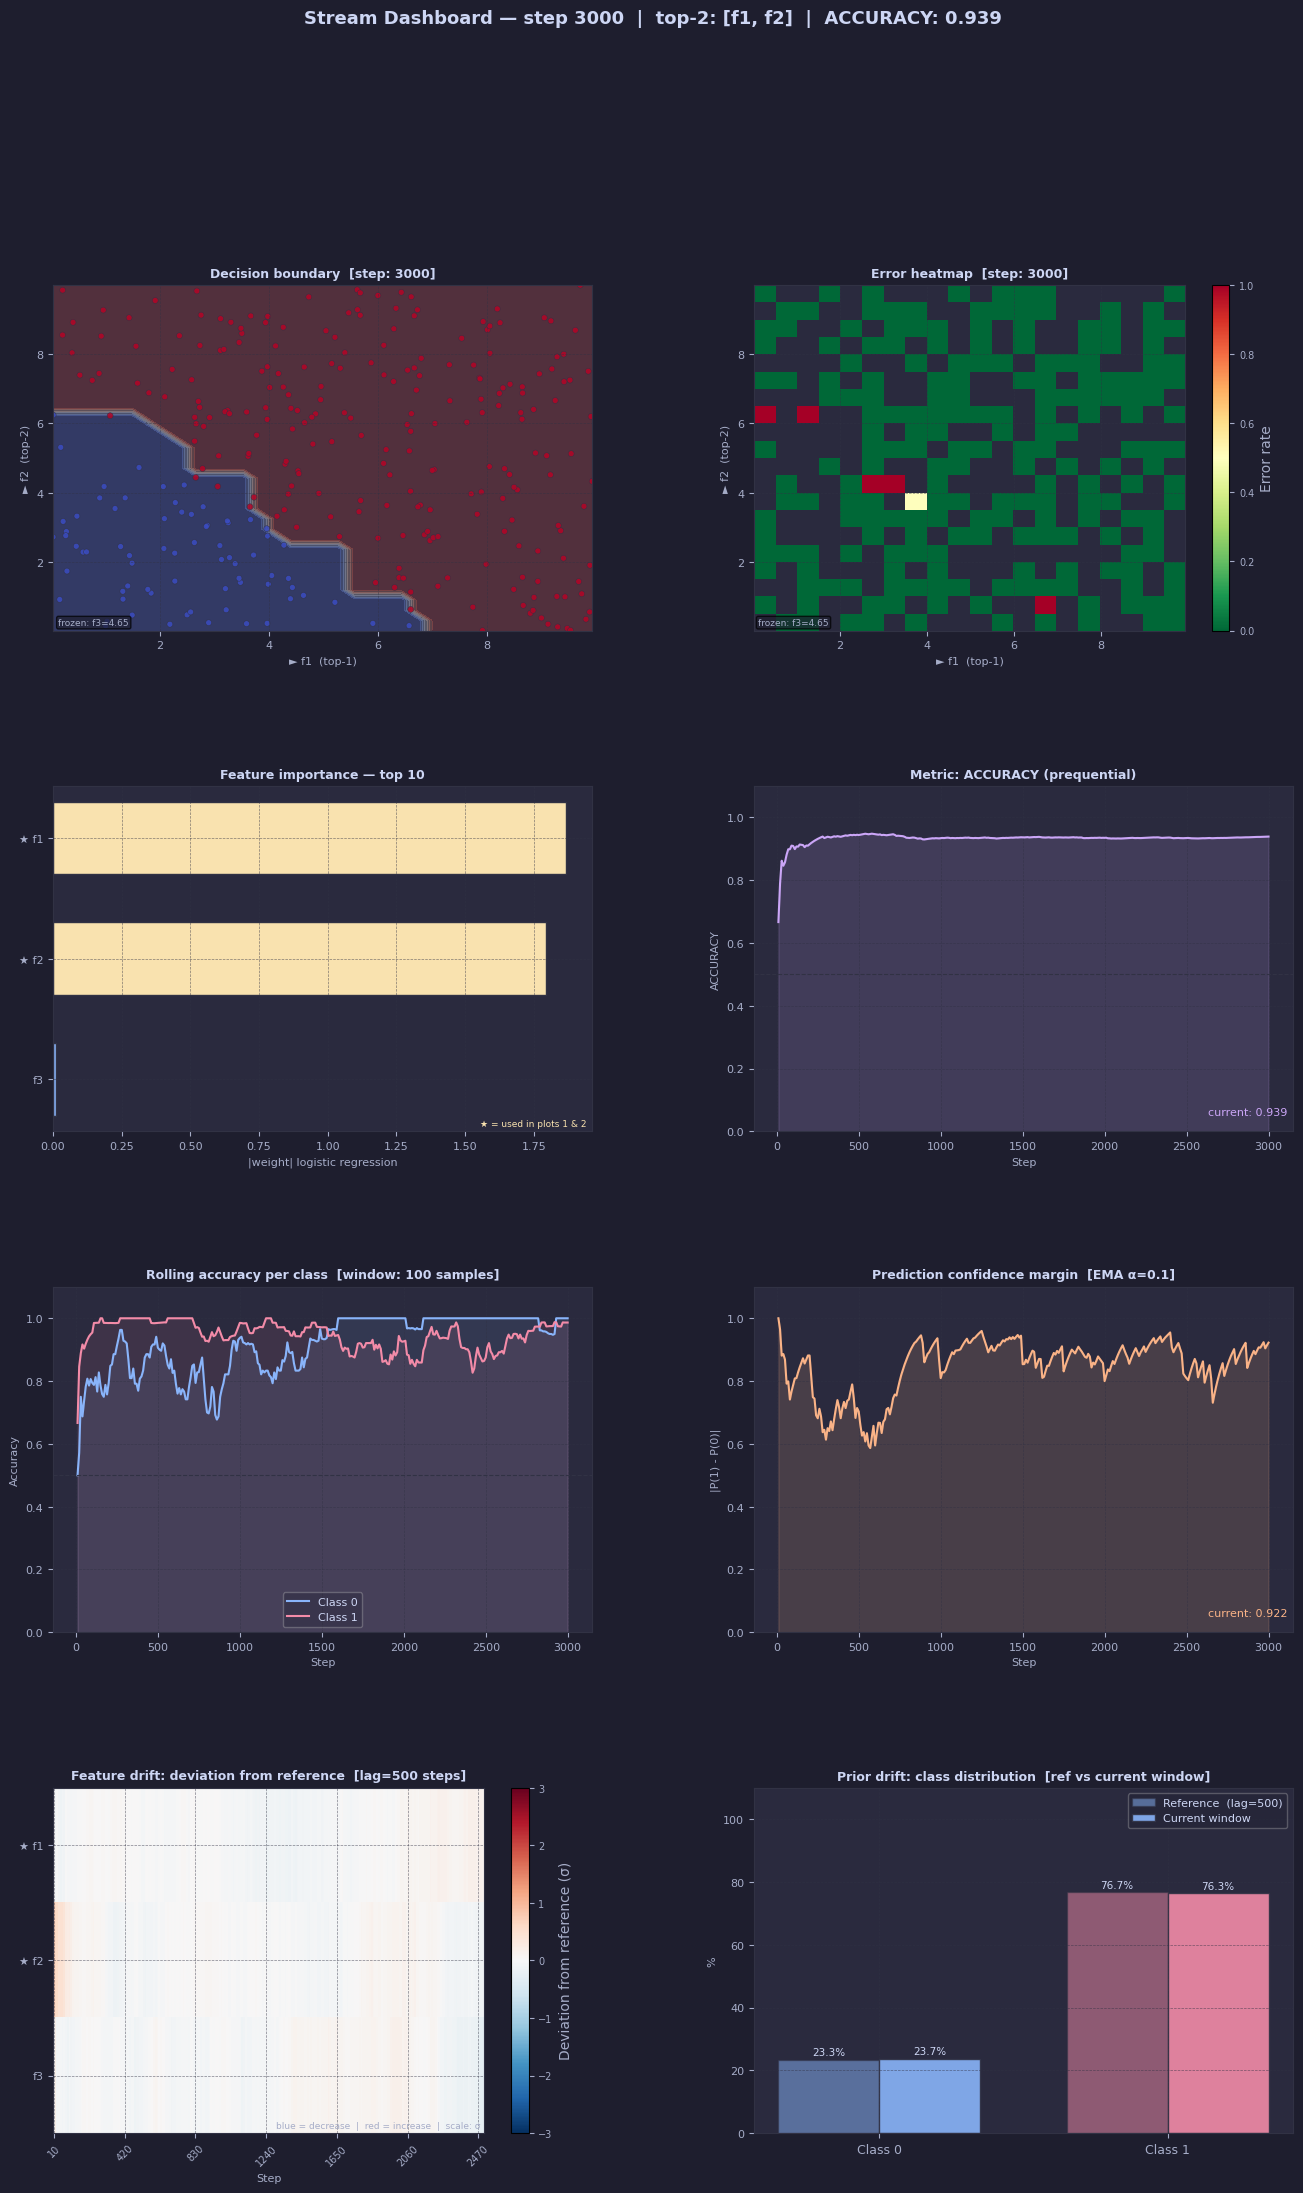

In [3]:
def sea_stream_with_drift(n_samples=3000, drift_point=1500):
    """
    SEA stream generator.
    """
    # Variant 0 (before drift): class 1 if f1 + f2 <= 8
    stream_before = datasets.synth.SEA(variant=0, seed=42)

    # Variant 2 (after drift): class 1 if f1 + f2 <= 7
    # (Only the threshold changes - this will cause abrupt Concept Drift)
    stream_after = datasets.synth.SEA(variant=2, seed=99)

    # First half
    for i, (x, y) in enumerate(stream_before):
        if i >= drift_point:
            break
        x_str = {f"f{k+1}": v for k, v in x.items()}
        yield x_str, y

    # Second half
    for i, (x, y) in enumerate(stream_after):
        if i >= (n_samples - drift_point):
            break
        x_str = {f"f{k+1}": v for k, v in x.items()}
        yield x_str, y

model_sea = tree.HoeffdingAdaptiveTreeClassifier(seed=42)

dashboard_sea = StreamDashboard(
    model=model_sea,
    feature_names=['f1', 'f2', 'f3'],
    metric_type='accuracy',
    window_size=300,
    ref_lag=500,
    update_freq=100
)

for step, (x, y) in enumerate(sea_stream_with_drift(n_samples=3000, drift_point=1500)):
    y_pred = model_sea.predict_one(x)
    dashboard_sea.update(x, y, y_pred)
    model_sea.learn_one(x, y)

## Example 2: Real-world IoT data — Occupancy Detection

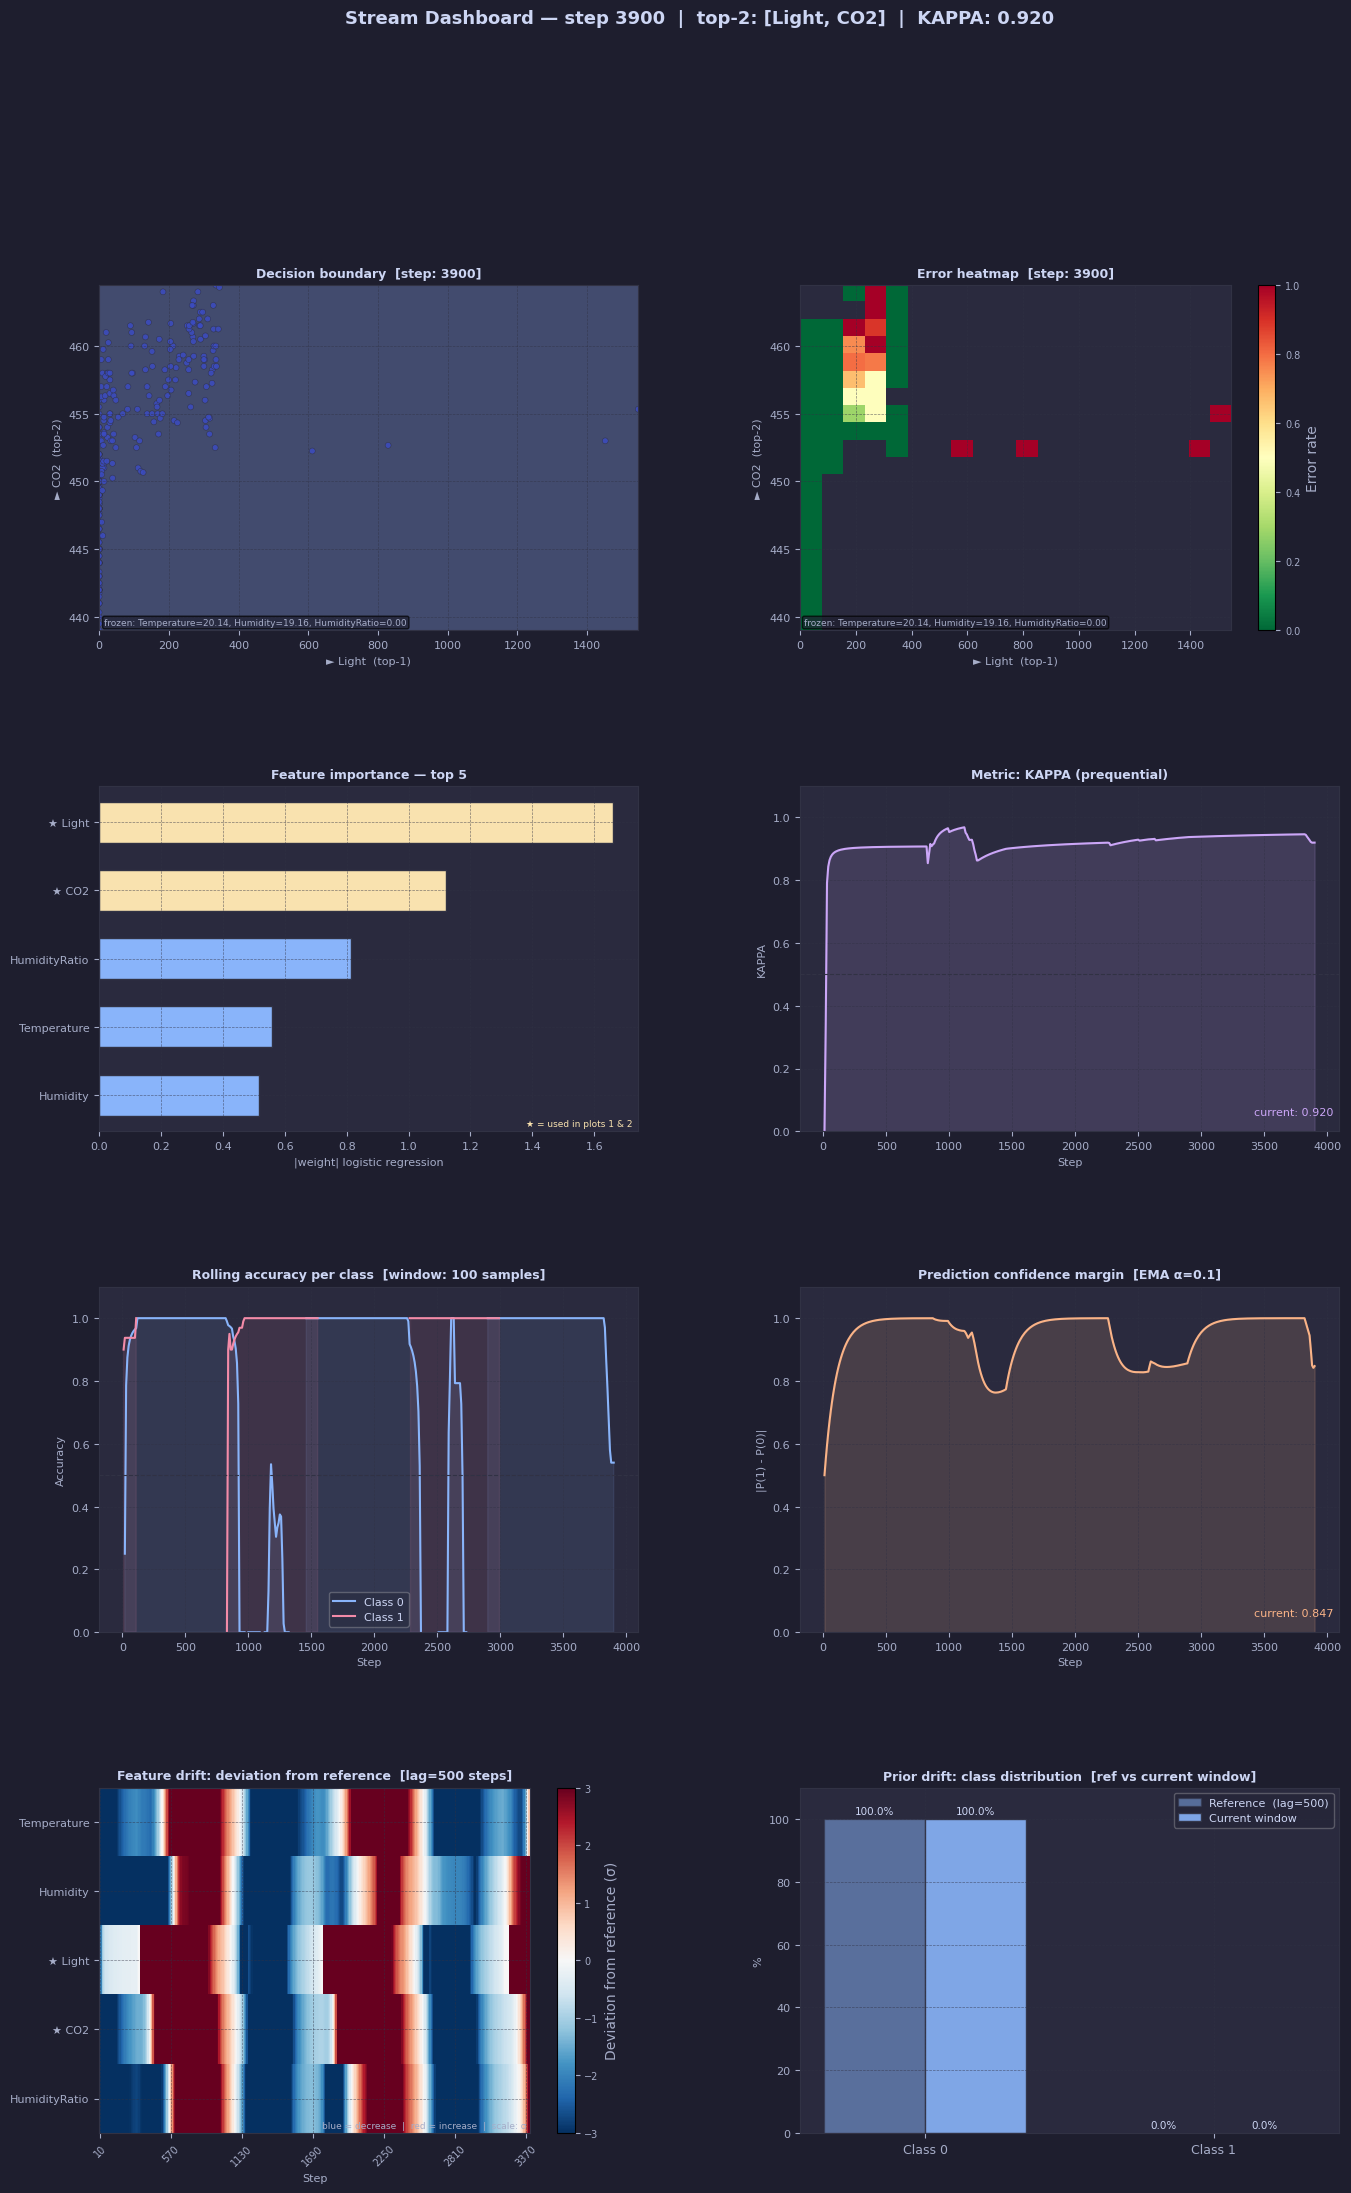

Concept drift detected at step 1152
Concept drift detected at step 1312


/tmp/ipykernel_10626/1858946908.py:288: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  im2 = self.ax2.imshow(
/tmp/ipykernel_10626/1858946908.py:288: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  im2 = self.ax2.imshow(
/tmp/ipykernel_10626/1858946908.py:288: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  im2 = self.ax2.imshow(
/tmp/ipykernel_10626/1858946908.py:288: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  im2 = self.ax2.imshow(
/tmp/ipykernel_10626/1858946908.py:288: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  im2 = self.ax2.imshow(
/tmp/ipykernel_10626/1858946908.py:288: UserWarning: Attempting to set identical low and high x

Concept drift detected at step 3840
Concept drift detected at step 3936


In [13]:
url = "https://raw.githubusercontent.com/LuisM78/Occupancy-detection-data/master/datatraining.txt"
df = pd.read_csv(url)

features = ['Temperature', 'Humidity', 'Light', 'CO2', 'HumidityRatio']
model_iot = tree.HoeffdingAdaptiveTreeClassifier(seed=42)
drift_detector = drift.ADWIN()

dashboard_iot = StreamDashboard(
    model_iot,
    feature_names=features,
    metric_type='kappa',
    update_freq=150,
    top_n_features=5
)

for i, (x, y) in enumerate(stream.iter_pandas(X=df[features], y=df['Occupancy'])):
    y_pred = model_iot.predict_one(x)

    if y_pred is not None:
        drift_detector.update(int(y_pred != y))
        if drift_detector.drift_detected:
            print(f"Concept drift detected at step {i}")

    dashboard_iot.update(x, y, y_pred)
    model_iot.learn_one(x, y)
    if i >= 4000:
        break

In [ ]:
## Example 3: Hyperplane Generator (continuous drift)

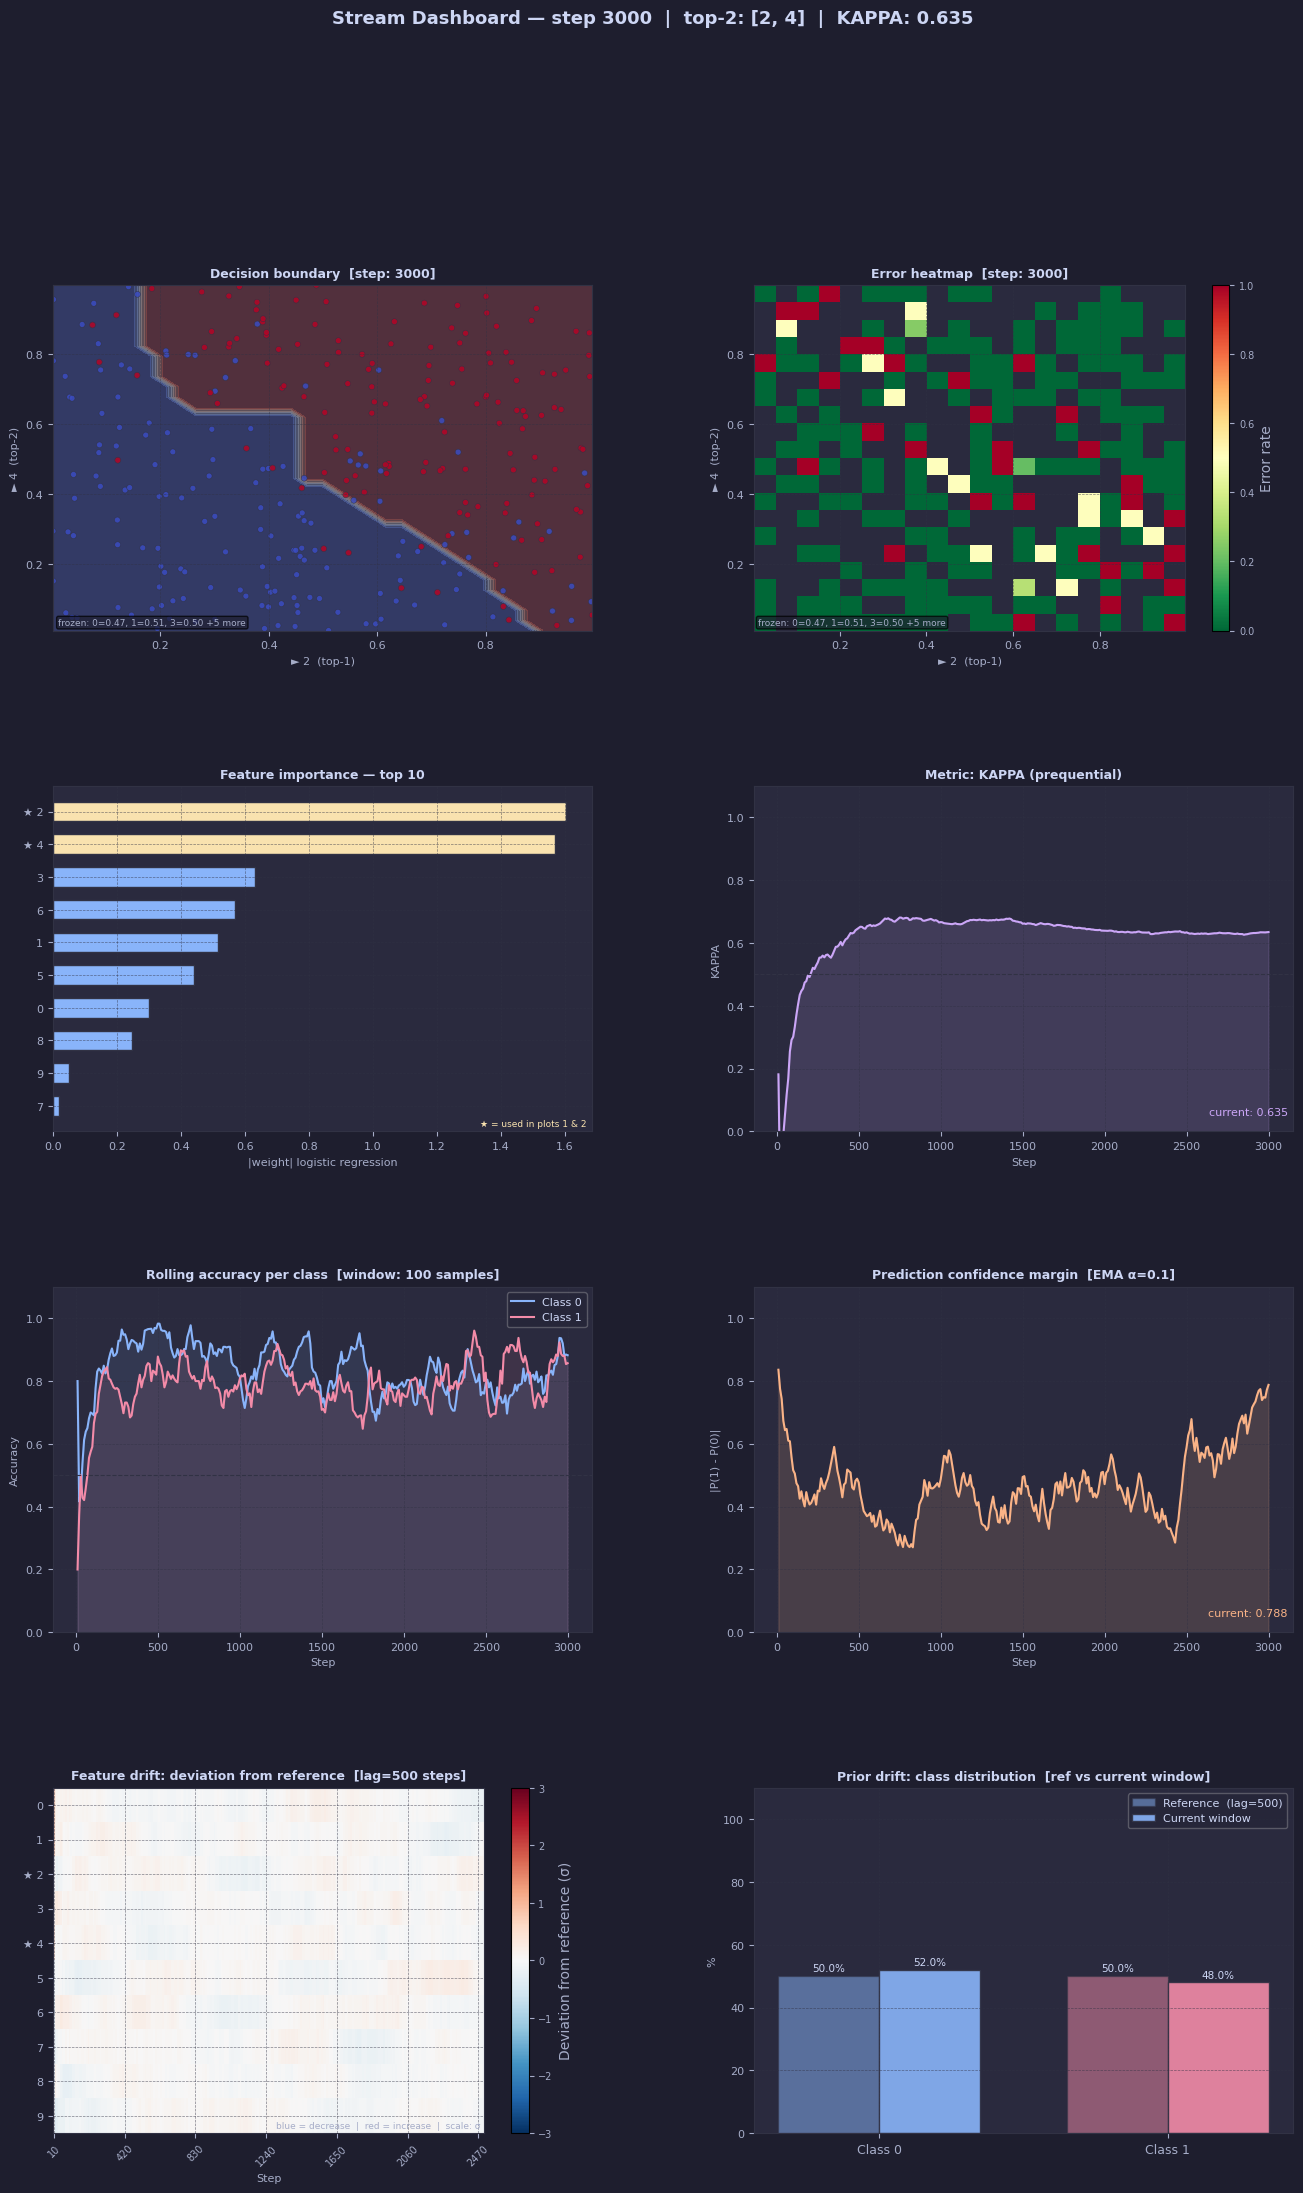

In [5]:
model_hp = tree.HoeffdingAdaptiveTreeClassifier(seed=42)
dashboard_hp = StreamDashboard(
    model_hp,
    feature_names=list(range(10)),
    metric_type='kappa',
    update_freq=100,
    top_n_features=10
)

stream = synth.Hyperplane(seed=42, n_features=10, n_drift_features=5, mag_change=0.01)

for x, y in stream.take(3000):
    y_pred = model_hp.predict_one(x)
    dashboard_hp.update(x, y, y_pred)
    model_hp.learn_one(x, y)

In [ ]:
## Example 4: real weather data

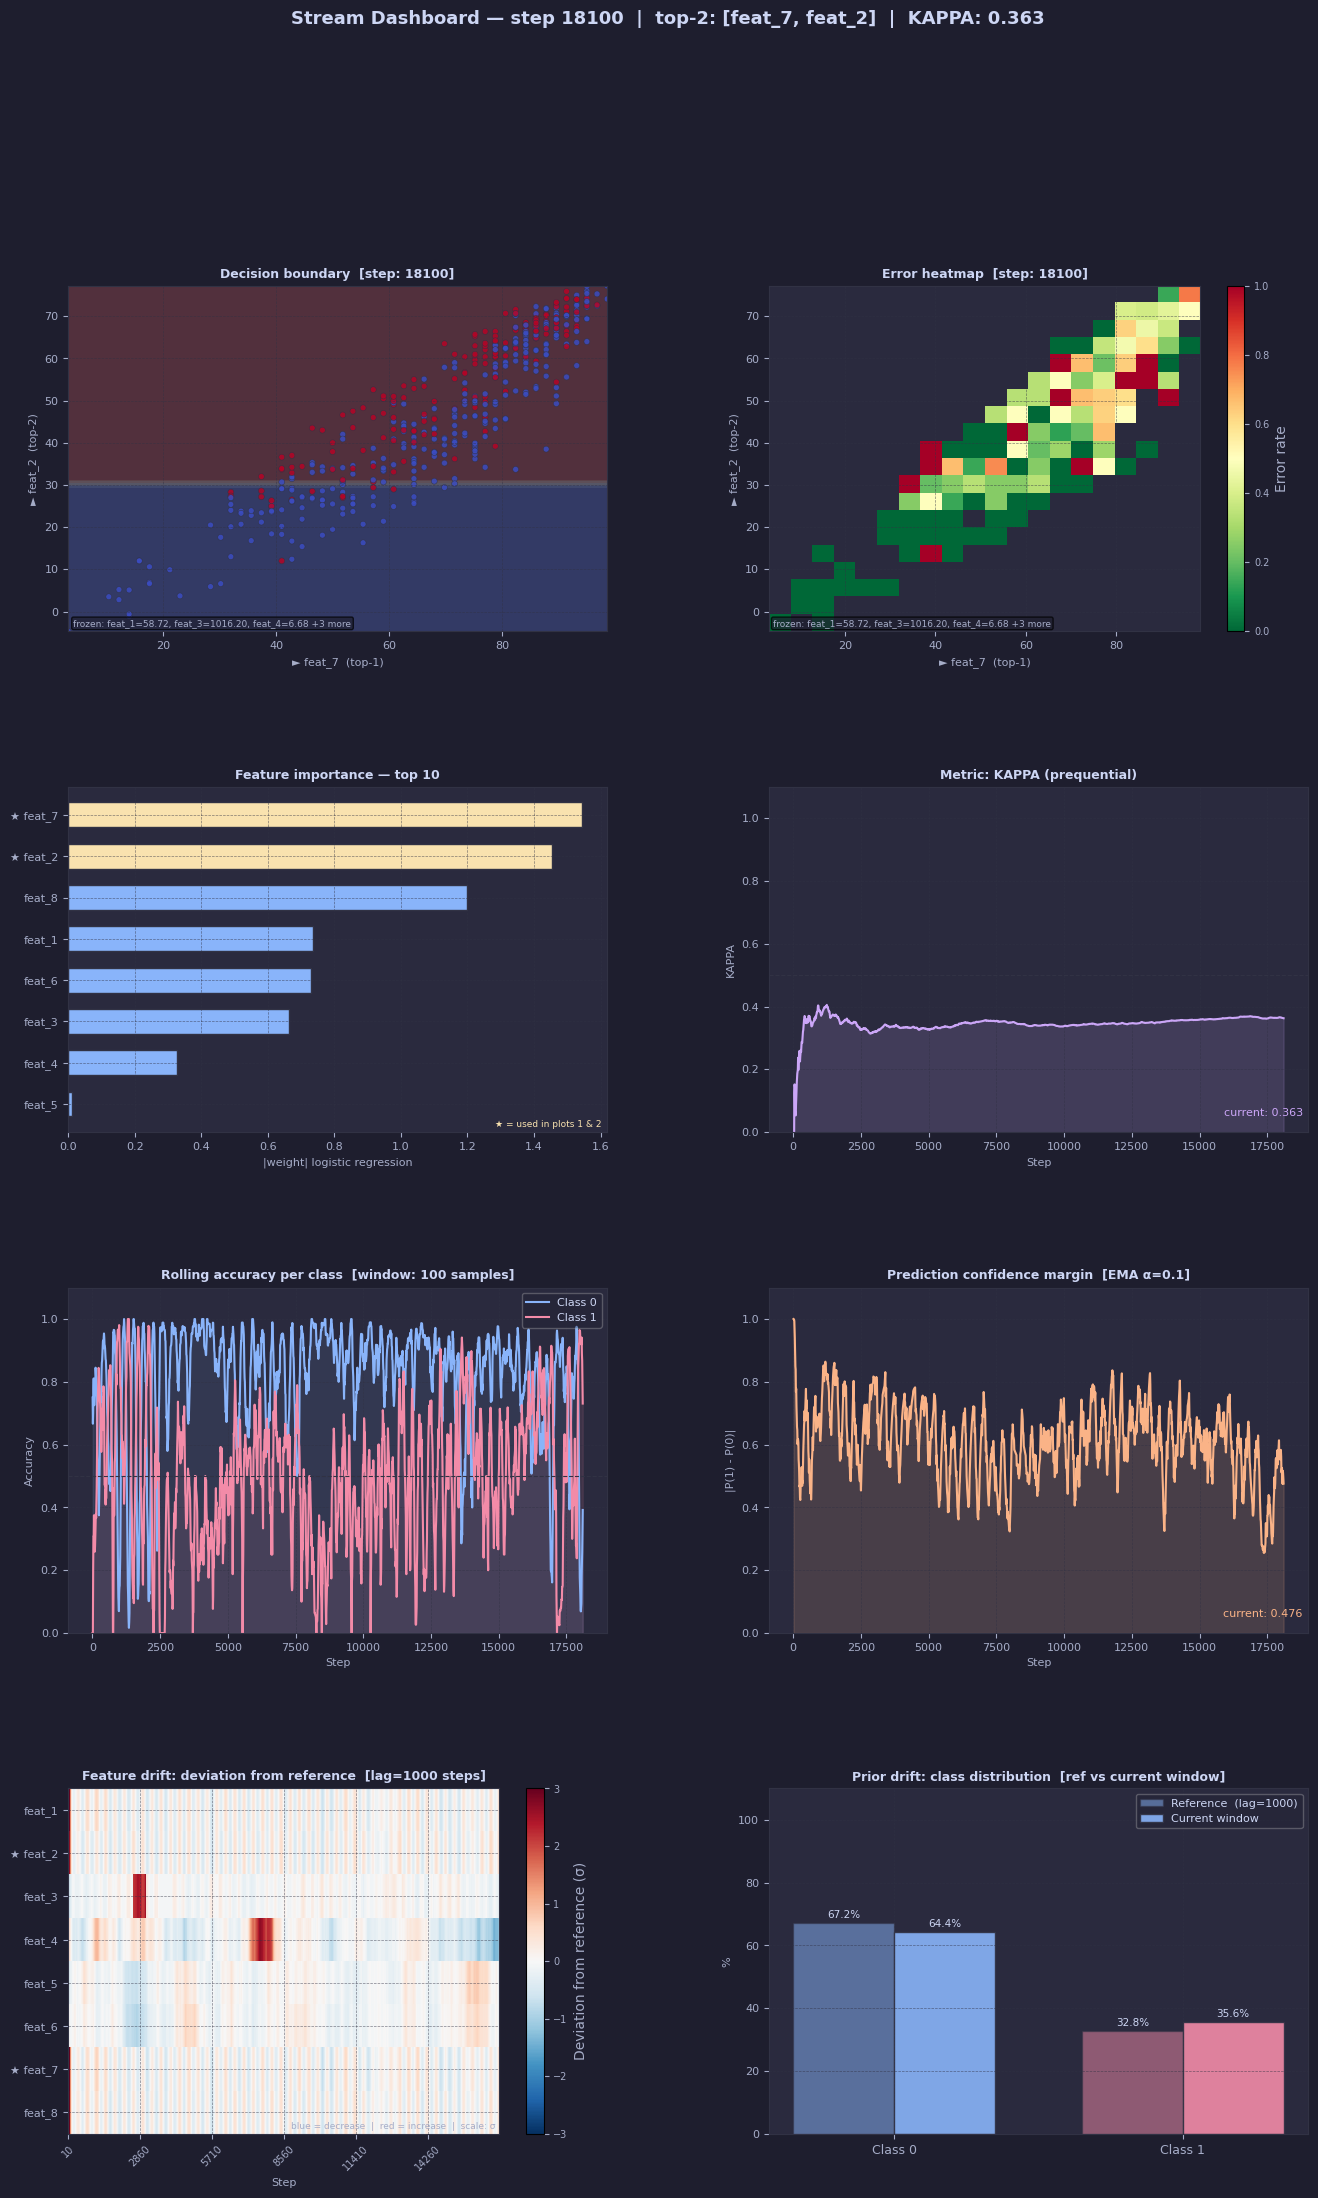

Concept drift detected at step 1344
Concept drift detected at step 1728
Concept drift detected at step 2080
Concept drift detected at step 3328
Concept drift detected at step 13344
Concept drift detected at step 16960
Concept drift detected at step 18048


In [14]:
URL = "https://raw.githubusercontent.com/ogozuacik/concept-drift-datasets-scikit-multiflow/master/real-world/weather.csv"

df = pd.read_csv(URL)
target_col = df.columns[-1]
features = df.columns[:-1].tolist()
df[target_col] = pd.factorize(df[target_col])[0]

def real_world_stream(dataframe, max_samples=None):
    for i, row in dataframe.iterrows():
        if max_samples and i >= max_samples:
            break
        x = {f: float(row[f]) for f in features}
        y = int(row[target_col])
        yield x, y

model_real = tree.HoeffdingAdaptiveTreeClassifier(seed=42)
drift_detector = drift.ADWIN()

dashboard_real = StreamDashboard(
    model=model_real,
    feature_names=features,
    metric_type='kappa',
    window_size=500,
    ref_lag=1000,
    update_freq=100,
    top_n_features=10
)

for step, (x, y) in enumerate(real_world_stream(df, max_samples=20000)):
    y_pred = model_real.predict_one(x)

    if y_pred is not None:
        drift_detector.update(int(y_pred != y))
        if drift_detector.drift_detected:
            print(f"Concept drift detected at step {step}")

    dashboard_real.update(x, y, y_pred)
    model_real.learn_one(x, y)